# CIFAR-10 SNGP Features and Uncertainty

Load a trained SNGP checkpoint, extract penultimate features and predictive uncertainty on the CIFAR-10 test set, then visualize the feature space with UMAP.

This follows the practical pipeline:
1. Extract penultimate features `h(x)` and uncertainty from the SNGP checkpoint.
2. Run UMAP on the features.
3. Visualize the 2D projection colored by class and by uncertainty.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import umap
import yaml

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from src.data.cifar10 import get_cifar10_loaders
from src.models.sngp import SNGPResNetClassifier, laplace_predictive_probs

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG_PATH = REPO_ROOT / "configs" / "cifar10_sngp.yaml"
CHECKPOINT_DIR = REPO_ROOT / "checkpoints_sngp"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoint dir:", CHECKPOINT_DIR)

device: cuda
checkpoint dir: /w/20252/wjcai/uq/manygp/checkpoints_sngp


In [3]:
def load_best_checkpoint(checkpoint_dir: Path, device: torch.device):
    checkpoint_paths = sorted(checkpoint_dir.glob("cifar10_sngp*.pt"))
    if not checkpoint_paths:
        raise FileNotFoundError(f"No SNGP checkpoints found in {checkpoint_dir}")

    best_checkpoint = None
    best_path = None
    best_score = float("-inf")

    for checkpoint_path in checkpoint_paths:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        score = checkpoint.get("val_accuracy")
        if score is None:
            continue
        if score > best_score:
            best_score = score
            best_checkpoint = checkpoint
            best_path = checkpoint_path

    if best_checkpoint is None or best_path is None:
        raise ValueError(f"No SNGP checkpoints with 'val_accuracy' found in {checkpoint_dir}")

    return best_path, best_checkpoint


BEST_CHECKPOINT_PATH, checkpoint = load_best_checkpoint(CHECKPOINT_DIR, device)
print("best checkpoint:", BEST_CHECKPOINT_PATH)
print("stored val accuracy:", checkpoint.get("val_accuracy"))
print("stored val nll:", checkpoint.get("val_nll"))

best checkpoint: /w/20252/wjcai/uq/manygp/checkpoints_sngp/cifar10_sngp_epoch100_acc0.9270.pt
stored val accuracy: 0.927
stored val nll: 0.35086657180786135


In [4]:
model_cfg = cfg["model"]
model = SNGPResNetClassifier(
    num_classes=model_cfg["num_classes"],
    width=model_cfg["width"],
    hidden_dim=model_cfg["hidden_dim"],
    spec_norm_bound=model_cfg["spec_norm_bound"],
    num_inducing=model_cfg["num_inducing"],
    ridge_penalty=model_cfg["ridge_penalty"],
    feature_scale=model_cfg["feature_scale"],
    gp_cov_momentum=model_cfg["gp_cov_momentum"],
    normalize_input=model_cfg["normalize_input"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("loaded epoch:", checkpoint.get("epoch"))

loaded epoch: 100


In [5]:
data_cfg = cfg["data"]
_, test_loader, _, test_dataset = get_cifar10_loaders(
    data_root=data_cfg["root"],
    batch_size=data_cfg["batch_size"],
    num_workers=0,
    smoke_test=False,
)
print("test size:", len(test_dataset))

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


test size: 10000


In [6]:
CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [7]:
@torch.no_grad()
def extract_sngp_features_and_uncertainty(model, loader, device, num_mc_samples=10):
    model.eval()
    features = []
    labels = []
    logits_list = []
    probs_list = []
    variances_list = []
    entropy_list = []
    preds_list = []

    for images, batch_labels in loader:
        images = images.to(device, non_blocking=True)
        batch_labels = batch_labels.to(device, non_blocking=True)

        batch_features = model.encode(images)
        batch_logits, batch_variances = model(images, return_cov=True)
        batch_probs = laplace_predictive_probs(batch_logits, batch_variances, num_mc_samples=num_mc_samples)
        batch_entropy = -(batch_probs.clamp_min(1e-12) * batch_probs.clamp_min(1e-12).log()).sum(dim=1)
        batch_preds = batch_probs.argmax(dim=1)

        features.append(batch_features.cpu())
        labels.append(batch_labels.cpu())
        logits_list.append(batch_logits.cpu())
        probs_list.append(batch_probs.cpu())
        variances_list.append(batch_variances.cpu())
        entropy_list.append(batch_entropy.cpu())
        preds_list.append(batch_preds.cpu())

    return {
        "features": torch.cat(features, dim=0),
        "labels": torch.cat(labels, dim=0),
        "logits": torch.cat(logits_list, dim=0),
        "probs": torch.cat(probs_list, dim=0),
        "variances": torch.cat(variances_list, dim=0),
        "entropy": torch.cat(entropy_list, dim=0),
        "preds": torch.cat(preds_list, dim=0),
    }


outputs = extract_sngp_features_and_uncertainty(
    model=model,
    loader=test_loader,
    device=device,
    num_mc_samples=cfg["training"].get("num_mc_samples", 10),
)

features = outputs["features"]
labels = outputs["labels"]
probs = outputs["probs"]
variances = outputs["variances"]
entropy = outputs["entropy"]
preds = outputs["preds"]

scalar_variance = variances.mean(dim=1)
correct_mask = preds.eq(labels)

print("features:", features.shape)
print("labels:", labels.shape)
print("mean variance shape:", scalar_variance.shape)
print("entropy shape:", entropy.shape)

features: torch.Size([10000, 128])
labels: torch.Size([10000])
mean variance shape: torch.Size([10000])
entropy shape: torch.Size([10000])


In [8]:
test_accuracy = correct_mask.float().mean().item()
test_nll = -probs.clamp_min(1e-12).log().gather(1, labels.unsqueeze(1)).mean().item()
print(f"Test accuracy: {test_accuracy * 100:.2f}%")
print(f"Test NLL: {test_nll:.4f}")

Test accuracy: 92.71%
Test NLL: 0.3525


In [9]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
embedding_2d = reducer.fit_transform(features.numpy())
embedding_2d.shape

/w/20252/wjcai/uq/manygp/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10000, 2)

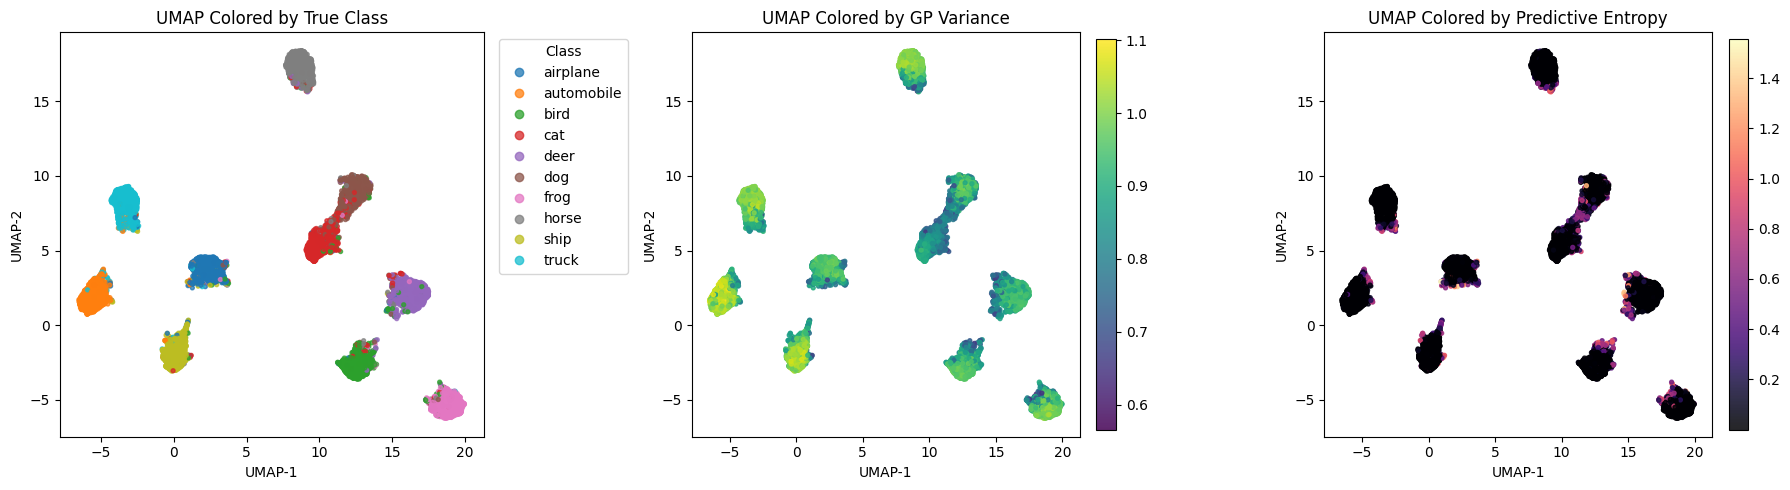

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter = axes[0].scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=labels.numpy(),
    cmap="tab10",
    s=8,
    alpha=0.75,
)
axes[0].set_title("UMAP Colored by True Class")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
handles, _ = scatter.legend_elements(num=len(CIFAR10_CLASSES))
axes[0].legend(handles, CIFAR10_CLASSES, title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")

var_plot = axes[1].scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=scalar_variance.numpy(),
    cmap="viridis",
    s=8,
    alpha=0.85,
)
axes[1].set_title("UMAP Colored by GP Variance")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")
plt.colorbar(var_plot, ax=axes[1], fraction=0.046, pad=0.04)

ent_plot = axes[2].scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    c=entropy.numpy(),
    cmap="magma",
    s=8,
    alpha=0.85,
)
axes[2].set_title("UMAP Colored by Predictive Entropy")
axes[2].set_xlabel("UMAP-1")
axes[2].set_ylabel("UMAP-2")
plt.colorbar(ent_plot, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

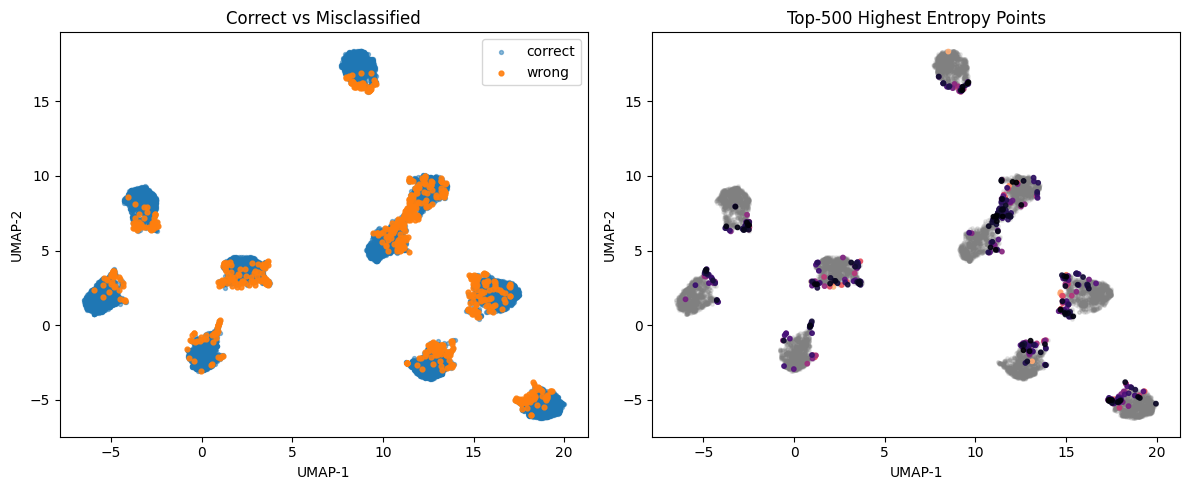

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    embedding_2d[correct_mask.numpy(), 0],
    embedding_2d[correct_mask.numpy(), 1],
    s=8,
    alpha=0.5,
    label="correct",
)
axes[0].scatter(
    embedding_2d[~correct_mask.numpy(), 0],
    embedding_2d[~correct_mask.numpy(), 1],
    s=12,
    alpha=0.9,
    label="wrong",
)
axes[0].set_title("Correct vs Misclassified")
axes[0].set_xlabel("UMAP-1")
axes[0].set_ylabel("UMAP-2")
axes[0].legend()

topk = torch.topk(entropy, k=500).indices.numpy()
axes[1].scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=6,
    alpha=0.15,
    color="gray",
)
axes[1].scatter(
    embedding_2d[topk, 0],
    embedding_2d[topk, 1],
    s=10,
    alpha=0.9,
    c=entropy[topk].numpy(),
    cmap="magma",
)
axes[1].set_title("Top-500 Highest Entropy Points")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()